# Chapter 2: Setting Up a Modern Deep Learning Development Environment

*Deep Learning Crash Course - BPB Publications*

Chapter 2 walks through the practical engineering work of getting a usable deep learning workstation: virtual environments, TensorFlow and PyTorch installation, GPU configuration, mixed precision, reproducibility, Jupyter, Colab, TensorBoard, Git and Docker.

Many of those steps are configuration commands rather than runnable Python. This notebook gathers the things that **are** runnable so you can verify each piece of your environment, and finishes with the chapter's exercise solutions.


## 1. Environment introspection

Run this cell first. It prints the Python version, the host OS, available CPU memory and whether NVIDIA tools are installed.

In [1]:
import os, sys, platform, subprocess, shutil
from pathlib import Path
import matplotlib.pyplot as plt

IMG_DIR = Path('images'); IMG_DIR.mkdir(exist_ok=True)

print('Python:', sys.version.split()[0])
print('Platform:', platform.platform())
print('Executable:', sys.executable)
print('Active venv:', os.environ.get('VIRTUAL_ENV', '<none>'))
print('CUDA tools on PATH:', shutil.which('nvcc'))
print('nvidia-smi on PATH:', shutil.which('nvidia-smi'))


Python: 3.12.3
Platform: Linux-5.15.133.1-microsoft-standard-WSL2-x86_64-with-glibc2.39
Executable: /home/samaresh/src/.venv/bin/python
Active venv: /home/samaresh/src/.venv
CUDA tools on PATH: None
nvidia-smi on PATH: /usr/lib/wsl/lib/nvidia-smi


## 2. Framework version and GPU smoke test

The verification script from the chapter — checks both frameworks, lists devices and runs a small matrix multiplication on each.

In [2]:
def check_tensorflow():
    try:
        import tensorflow as tf
        print(f'TensorFlow: {tf.__version__}')
        gpus = tf.config.list_physical_devices('GPU')
        print(f'  visible GPUs: {len(gpus)}')
        for g in gpus:
            print('    ', g)
        device = '/GPU:0' if gpus else '/CPU:0'
        with tf.device(device):
            a = tf.random.normal((512, 512))
            b = tf.random.normal((512, 512))
            c = tf.matmul(a, b)
            print(f'  matmul on {device} -> shape {c.shape}, sum {float(tf.reduce_sum(c)):.2f}')
    except Exception as e:
        print('TensorFlow not available:', type(e).__name__, e)

def check_pytorch():
    try:
        import torch
        print(f'PyTorch: {torch.__version__}')
        print(f'  CUDA available: {torch.cuda.is_available()}')
        print(f'  CUDA devices: {torch.cuda.device_count()}')
        if hasattr(torch.backends, "mps"):
            print(f'  MPS available: {torch.backends.mps.is_available()}')
        device = 'cuda' if torch.cuda.is_available() else 'mps' if (hasattr(torch.backends, 'mps') and torch.backends.mps.is_available()) else 'cpu'
        a = torch.randn(512, 512, device=device)
        b = torch.randn(512, 512, device=device)
        c = a @ b
        print(f'  matmul on {device} -> shape {tuple(c.shape)}, sum {float(c.sum()):.2f}')
    except Exception as e:
        print('PyTorch not available:', type(e).__name__, e)

check_tensorflow()
print()
check_pytorch()


TensorFlow: 2.20.0
  visible GPUs: 1
     PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')


I0000 00:00:1778973136.203913  542190 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 5561 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4060 Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.9


  matmul on /GPU:0 -> shape (512, 512), sum -2690.66

PyTorch: 2.10.0+cu128
  CUDA available: True
  CUDA devices: 1
  MPS available: False
  matmul on cuda -> shape (512, 512), sum -1462.66


## 3. Reproducibility helpers

Reproducibility is the single biggest source of "works on my machine" frustration. Set every seed you can find — and disable nondeterministic kernels when accuracy matters more than speed.

In [3]:
import random
import numpy as np

def set_global_seed(seed=42):
    """Seed Python, NumPy, TensorFlow and PyTorch in one call."""
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    try:
        import tensorflow as tf
        tf.random.set_seed(seed)
    except ModuleNotFoundError:
        pass
    try:
        import torch
        torch.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # full determinism (slower):
        # torch.use_deterministic_algorithms(True)
    except ModuleNotFoundError:
        pass
    print(f'All seeds set to {seed}')

set_global_seed(42)


All seeds set to 42


## 4. Mixed-precision smoke test (PyTorch)

Mixed precision stores activations in float16 / bfloat16 but keeps a master copy of the weights in float32. The block below exercises an `autocast` block and a `GradScaler` so you can confirm the wiring runs end-to-end.

In [4]:
try:
    import torch
    import torch.nn as nn
    device = 'cuda' if torch.cuda.is_available() else 'cpu'
    model = nn.Sequential(nn.Linear(256, 256), nn.ReLU(), nn.Linear(256, 10)).to(device)
    x = torch.randn(64, 256, device=device)
    y = torch.randint(0, 10, (64,), device=device)
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    use_amp = device == 'cuda'
    scaler = torch.amp.GradScaler('cuda') if use_amp else None
    for _ in range(3):
        opt.zero_grad()
        with torch.amp.autocast(device_type=device, enabled=use_amp):
            logits = model(x); loss = nn.functional.cross_entropy(logits, y)
        if use_amp:
            scaler.scale(loss).backward(); scaler.step(opt); scaler.update()
        else:
            loss.backward(); opt.step()
    print(f'AMP enabled: {use_amp} | final loss: {loss.item():.4f}')
except ModuleNotFoundError:
    print('PyTorch not installed - skipping mixed precision demo.')


AMP enabled: True | final loss: 1.9959


## 5. Detecting and pinning dependencies

Pinning the exact versions of the libraries you use is what makes a notebook still work in two years. Use `pip freeze` for a strict lock file and a `requirements.txt` for the small, hand-curated set of top-level packages.

In [5]:
import importlib
important = ['numpy', 'pandas', 'sklearn', 'matplotlib', 'tensorflow',
             'torch', 'transformers', 'huggingface_hub', 'datasets']
for name in important:
    try:
        m = importlib.import_module(name)
        v = getattr(m, '__version__', '?')
        print(f'{name:18s} {v}')
    except ModuleNotFoundError:
        print(f'{name:18s} <not installed>')


numpy              2.3.5
pandas             3.1.0.dev0+605.g10682ff6e9.dirty
sklearn            1.8.0
matplotlib         3.10.7
tensorflow         2.20.0
torch              2.10.0+cu128
transformers       5.5.4
huggingface_hub    1.5.0
datasets           4.2.0


## 6. Toy training run with TensorBoard

TensorBoard works with both Keras and PyTorch. The cell below trains a tiny model for two epochs and writes scalar + histogram data to `runs/`. Launch with `tensorboard --logdir runs/` from a terminal.

In [6]:
try:
    import torch
    from torch.utils.tensorboard import SummaryWriter
    set_global_seed(0)
    writer = SummaryWriter(log_dir='runs/ch02_demo')
    model = torch.nn.Sequential(torch.nn.Linear(10, 32), torch.nn.ReLU(), torch.nn.Linear(32, 2))
    opt = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn = torch.nn.CrossEntropyLoss()
    for step in range(200):
        x = torch.randn(32, 10); y = (x.sum(axis=1) > 0).long()
        opt.zero_grad(); out = model(x); loss = loss_fn(out, y); loss.backward(); opt.step()
        writer.add_scalar('loss/train', loss.item(), step)
        if step % 20 == 0:
            for name, p in model.named_parameters():
                writer.add_histogram(name, p.detach(), step)
    writer.close()
    print('Wrote runs/ch02_demo - launch TensorBoard with: tensorboard --logdir runs/')
except ModuleNotFoundError:
    print('PyTorch / TensorBoard not installed - skipping.')


All seeds set to 0
Wrote runs/ch02_demo - launch TensorBoard with: tensorboard --logdir runs/


## 7. Plotting a small CPU vs GPU benchmark

We measure matmul throughput across a few sizes and save the figure to the image bundle. On CPU-only machines, the GPU line will be skipped.

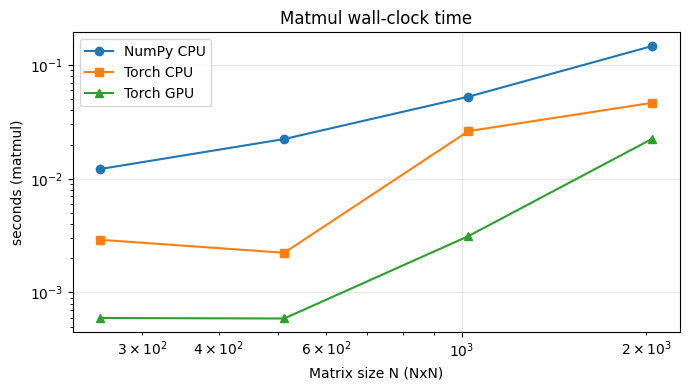

In [8]:
import time
import numpy as np
import matplotlib.pyplot as plt

def benchmark_numpy(sizes):
    times = []
    for n in sizes:
        a, b = np.random.randn(n, n), np.random.randn(n, n)
        t0 = time.perf_counter(); _ = a @ b; times.append(time.perf_counter() - t0)
    return times

def benchmark_torch(sizes, device):
    import torch
    times = []
    for n in sizes:
        a = torch.randn(n, n, device=device); b = torch.randn(n, n, device=device)
        if device == 'cuda': torch.cuda.synchronize()
        t0 = time.perf_counter(); c = a @ b
        if device == 'cuda': torch.cuda.synchronize()
        times.append(time.perf_counter() - t0)
    return times

sizes = [256, 512, 1024, 2048]
numpy_times = benchmark_numpy(sizes)
try:
    import torch
    torch_cpu = benchmark_torch(sizes, 'cpu')
    torch_gpu = benchmark_torch(sizes, 'cuda') if torch.cuda.is_available() else None
except ModuleNotFoundError:
    torch_cpu = torch_gpu = None

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sizes, numpy_times, 'o-', label='NumPy CPU')
if torch_cpu: ax.plot(sizes, torch_cpu, 's-', label='Torch CPU')
if torch_gpu: ax.plot(sizes, torch_gpu, '^-', label='Torch GPU')
ax.set_xlabel('Matrix size N (NxN)'); ax.set_ylabel('seconds (matmul)')
ax.set_yscale('log'); ax.set_xscale('log'); ax.grid(alpha=0.3); ax.legend()
ax.set_title('Matmul wall-clock time')
fig.tight_layout(); fig.savefig(IMG_DIR / '01_matmul_bench.png', dpi=150); plt.show()


## 8. Exercise solutions

### 8.1 Multiple-choice answers

| Q | Answer | Why |
|---|--------|-----|
| 1 | (b) Isolates project dependencies | Each project gets its own Python + packages. |
| 2 | (c) PyTorch | Dynamic graph and Pythonic API dominate the research literature. |
| 3 | (a) NVIDIA driver, CUDA toolkit, cuDNN | Three layers required for accelerated DL on NVIDIA. |
| 4 | (b) `%matplotlib inline` | Renders plots in-place inside the notebook. |
| 5 | (c) Mount Google Drive | Otherwise the runtime VM is wiped at the end of the session. |
| 6 | (d) Scalars | The tab where train vs val curves diverge is the easiest diagnostic. |
| 7 | (b) Model weight files | `*.h5`, `*.pt`, checkpoints. Bytes-heavy and not source. |
| 8 | (c) MPS (Metal Performance Shaders) | Apple's GPU backend for PyTorch on M-series. |
| 9 | (c) Faster training with less memory at near-equivalent accuracy | The headline benefit of fp16/bf16. |
| 10 | (b) Reproduces the entire OS-level environment | Drivers, libs, env — not just Python packages. |


### 8.2 venv vs conda
**venv** ships with Python and only manages Python packages. It is fast and lightweight, but it cannot install non-Python binaries (CUDA, cuDNN, ffmpeg).

**conda** manages both Python packages *and* compiled system libraries from its own binary channels. It is the right choice when (a) you do not have admin rights to install system CUDA, (b) you want a pinned cuDNN that matches a specific TensorFlow build, or (c) you need non-Python tools (`ffmpeg`, `graphviz`) installed alongside Python. A common pattern is to use conda to provision the system libraries and `pip install` Python packages inside that conda environment.

### 8.3 NVIDIA software stack — three layers
1. **Driver**: kernel-level software that talks to the GPU hardware. Without it, `nvidia-smi` cannot see the device.
2. **CUDA toolkit**: user-level libraries (`libcudart`, `nvcc`) that expose the GPU to programs. The toolkit must be ABI-compatible with the driver and with the framework.
3. **cuDNN**: tuned primitives for convolutions, RNNs and matmuls. TensorFlow and PyTorch both bundle / load cuDNN at runtime. A mismatched cuDNN is the most common cause of opaque CUDA crashes.

### 8.4 Three reasons a notebook produces different results each run
1. **Unseeded RNG** in NumPy / TensorFlow / PyTorch — fix with `set_global_seed` above and explicit `random_state=` everywhere `sklearn` exposes one.
2. **CUDA non-determinism**: some kernels (e.g. atomicAdd reductions) are non-deterministic. Fix with `torch.use_deterministic_algorithms(True)` and `CUBLAS_WORKSPACE_CONFIG=:4096:8`.
3. **Data ordering**: `tf.data.Dataset` with `shuffle()` but no `seed`, or a DataLoader without `generator=`. Pass an explicit seed to every shuffle.


In [9]:
# Demonstrating that the same code with the same seed reproduces
set_global_seed(123)
a = np.random.randn(5)
set_global_seed(123)
b = np.random.randn(5)
print('Identical:', np.allclose(a, b))


All seeds set to 123
All seeds set to 123
Identical: True


### 8.5 Choosing between local Jupyter, Colab and VS Code for a 6-month project
- **Local Jupyter** is the safest for a 6-month project: full control, your data stays local, no session expiry.
- **Google Colab** is good for sharing or zero-setup demos but the runtime is ephemeral and free tier disconnects after ~12 hours. Use **Colab Pro** if you rely on long-running training.
- **VS Code** with the Jupyter extension combines the notebook UX with a real editor (refactoring, type checking, multi-file projects).

Recommendation for a 6-month project: VS Code attached to a remote workstation. You get the editor, the kernel runs on the GPU box and notebooks are version controlled in Git on your laptop.

### 8.6 Git branching strategy for a four-person ML team
Use **trunk-based development** with short-lived feature branches:
- `main` — always shippable; protected (PR + 1 approval + CI green required).
- `feat/<topic>-<initials>` — one feature per branch, rebased onto `main` before merge.
- `exp/<topic>-<initials>` — research branches that may never merge; deleted after the experiment is written up.
- `hotfix/<issue-number>` — emergency fixes, fast-forward merge.

Merge policy: **squash and merge** so `main` keeps one commit per feature. Use **conventional-commit** prefixes (`feat:`, `fix:`, `chore:`, `data:`, `paper:`) so the changelog is auto-generated.

### 8.7 "CUDA out of memory" troubleshooting playbook
When training BERT-base on a 16 GB GPU OOMs, try, in order:
1. **Reduce micro-batch size** and use `gradient_accumulation_steps` to keep the effective batch the same.
2. **Enable mixed precision** (`fp16` or `bf16`) — halves activation memory.
3. **Gradient checkpointing** (`model.gradient_checkpointing_enable()` in HF Transformers) — trades extra compute for ~30-40% memory.
4. **Shorter sequence length** — attention memory is $O(L^2)$ so trimming from 512 to 384 saves substantial memory.
5. **Optimizer state offload** (`bitsandbytes` 8-bit Adam, DeepSpeed ZeRO-2) moves optimizer state to CPU.
6. **Remove any unused tensors** in your forward pass and explicitly call `torch.cuda.empty_cache()` between epochs.

### 8.8 Docker vs venv
venv pins **Python packages** only. Docker also pins the **operating system, compiled libraries and tooling** (Python version, CUDA, cuDNN, system compilers, fonts, locales, environment variables). Two failure modes that a venv cannot prevent:
1. The notebook uses `cv2.imdecode` which depends on a particular `libjpeg-turbo` version present on the original Ubuntu image but not on the reviewer's macOS machine.
2. The training script silently picks up a different cuDNN at runtime on the reviewer's CUDA 11.8 server vs your CUDA 12.4 box, giving different numerical results.

A `Dockerfile` baked from `nvidia/cuda:12.4.1-cudnn-devel-ubuntu22.04` and copied into a CI pipeline is the only way to make those failures impossible.

---
*End of Chapter 2 — verification figures saved to `images/`.*
